In [5]:
pip install pandas numpy nltk matplotlib seaborn wordcloud scikit-learn jupyter

   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   -------------------- ------------------- 0.8/1.6 MB 2.5 MB/s eta 0:00:01
   --------------------------------- ------ 1.3/1.6 MB 2.6 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 2.4 MB/s  0:00:00
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.3 MB 3.1 MB/s eta 0:00:03
   -------- ------------------------------- 1.8/8.3 MB 3.2 MB/s eta 0:00:03
   ----------- ---------------------------- 2.4/8.3 MB 2.9 MB/s eta 0:00:03
   ------------ --------------------------- 2.6/8.3 MB 2.7 MB/s eta 0:00:03
   --------------- ------------------------ 3.1/8.3 MB 2.7 MB/s eta 0:00:02
   ----------------- ---------------------- 3.7/8.3 MB 2.6 MB/s eta 0:00:02
   ------------------ ---------------------


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd

df = pd.read_csv("../sentiment analysis.csv")

df.head()

,Complaint ID,Category,Sub Category,Grievance Date,Ward Name,Grievance Status,Staff Remarks,Staff Name
0,20771690,Electrical,Street Light Not Working,2025-06-19 10:39:00.000000000,Jagajeevanram Nagar,Registered,1st Assignment Based on Ward Mapping,syed zameer/JE
1,20771689,Electrical,Street Light Not Working,2025-06-19 10:36:00.000000000,Kammanahalli,Registered,1st Assignment Based on Ward Mapping,Vinay Kumar/AE
2,20771688,Solid Waste (Garbage) Related,Garbage dump,2025-06-19 10:35:00.000000000,Banaswadi,Registered,1st Assignment Based on Ward Mapping,Marshal Ward No 27/Marshal
3,20771687,Electrical,Street Light Not Working,2025-06-19 10:34:00.000000000,Gandhi Nagar,Registered,1st Assignment Based on Ward Mapping,syed zameer/JE
4,20771686,Solid Waste (Garbage) Related,Garbage dump,2025-06-19 10:34:00.000000000,Kumaraswamy Layout,Registered,1st Assignment Based on Ward Mapping,Marshal Ward No 181/Marshal


In [7]:
df.shape

df.columns

df.info()

df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 126974 entries, 0 to 126973
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   Complaint ID      126974 non-null  int64
 1   Category          126974 non-null  str  
 2   Sub Category      126974 non-null  str  
 3   Grievance Date    126974 non-null  str  
 4   Ward Name         126974 non-null  str  
 5   Grievance Status  126920 non-null  str  
 6   Staff Remarks     126920 non-null  str  
 7   Staff Name        126920 non-null  str  
dtypes: int64(1), str(7)
memory usage: 7.8 MB


Complaint ID         0
Category             0
Sub Category         0
Grievance Date       0
Ward Name            0
Grievance Status    54
Staff Remarks       54
Staff Name          54
dtype: int64

In [8]:
df.dropna(inplace=True)

df.drop_duplicates(inplace=True)

df.shape

(126920, 8)

In [9]:
import re

def clean_text(text):
    
    text = str(text).lower()
    
    text = re.sub(r'http\S+', '', text)
    
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    text = re.sub(r'\s+', ' ', text)
    
    return text.strip()

In [10]:
df['clean_text'] = df['Sub Category'].apply(clean_text)

df[['Sub Category','clean_text']].head()

,Sub Category,clean_text
0,Street Light Not Working,street light not working
1,Street Light Not Working,street light not working
2,Garbage dump,garbage dump
3,Street Light Not Working,street light not working
4,Garbage dump,garbage dump


In [11]:
import nltk

nltk.download('punkt')

nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Global\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Global\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [24]:
import re

def clean_text(text):
    
    text = str(text).lower()
    
    text = re.sub(r'http\S+', '', text)
    
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    text = re.sub(r'\s+', ' ', text)
    
    return text.strip()

df['clean_text'] = df['Sub Category'].apply(clean_text)

df[['Sub Category', 'clean_text']].head()

,Sub Category,clean_text
0,Street Light Not Working,street light not working
1,Street Light Not Working,street light not working
2,Garbage dump,garbage dump
3,Street Light Not Working,street light not working
4,Garbage dump,garbage dump


In [25]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    
    words = word_tokenize(text)
    
    filtered = [word for word in words if word not in stop_words]
    
    return " ".join(filtered)

df['clean_text'] = df['clean_text'].apply(remove_stopwords)

df[['Sub Category','clean_text']].head()

,Sub Category,clean_text
0,Street Light Not Working,street light working
1,Street Light Not Working,street light working
2,Garbage dump,garbage dump
3,Street Light Not Working,street light working
4,Garbage dump,garbage dump


In [26]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Global\AppData\Roaming\nltk_data...


True

In [28]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    
    words = text.split()
    
    words = [lemmatizer.lemmatize(word) for word in words]
    
    return " ".join(words)

df['clean_text'] = df['clean_text'].apply(lemmatize_text)

df[['Sub Category','clean_text']].head()

,Sub Category,clean_text
0,Street Light Not Working,street light working
1,Street Light Not Working,street light working
2,Garbage dump,garbage dump
3,Street Light Not Working,street light working
4,Garbage dump,garbage dump


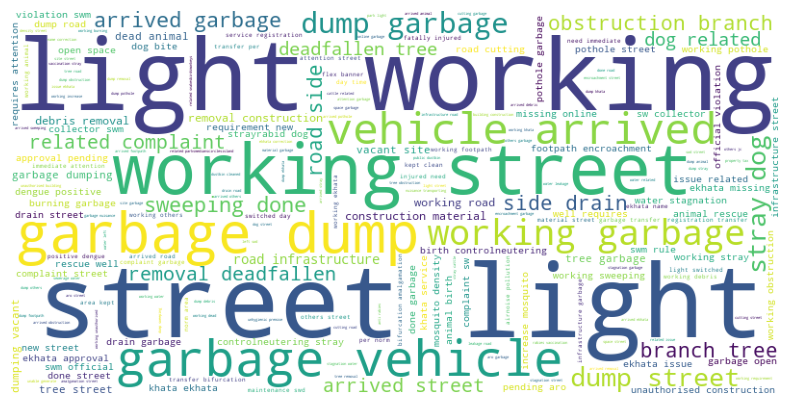

In [29]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df['clean_text'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis('off')

plt.show()

In [30]:
from collections import Counter

all_words = " ".join(df['clean_text']).split()

word_freq = Counter(all_words)

word_freq.most_common(10)

[('light', 41828),
 ('street', 41725),
 ('working', 40106),
 ('garbage', 32154),
 ('dump', 16129),
 ('vehicle', 12130),
 ('arrived', 12130),
 ('road', 7404),
 ('tree', 6040),
 ('dog', 5222)]

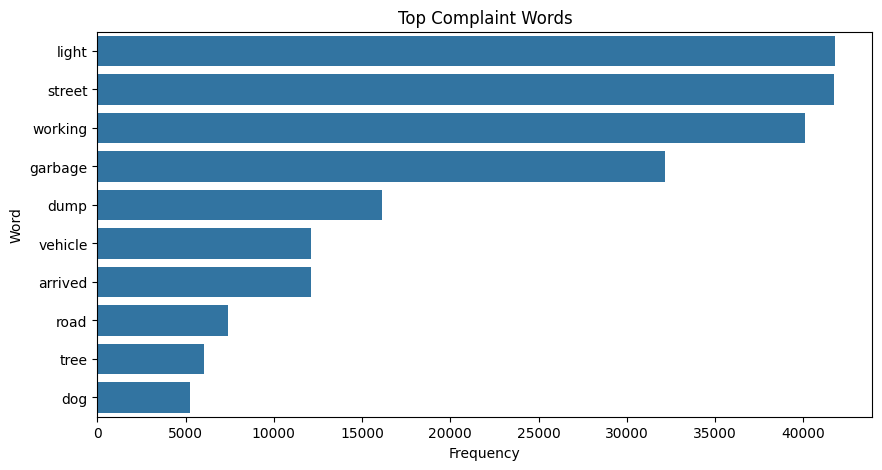

In [31]:
import seaborn as sns

top_words = pd.DataFrame(
    word_freq.most_common(10),
    columns=['Word','Frequency']
)

plt.figure(figsize=(10,5))

sns.barplot(
    x='Frequency',
    y='Word',
    data=top_words
)

plt.title("Top Complaint Words")

plt.show()